In [2]:
!pip install xarray netCDF4
! pip install matplotlib seaborn

In [3]:
import sys
!{sys.executable} -m pip install scikit-learn

In [4]:
!{sys.executable} -m pip install -r requirements.txt

  Using cached accelerate-1.10.1-py3-none-any.whl.metadata (19 kB)
  Using cached aiofiles-25.1.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached aiohappyeyeballs-2.6.1-py3-none-any.whl.metadata (5.9 kB)
  Using cached aiohttp-3.10.11-cp310-cp310-macosx_11_0_arm64.whl.metadata (7.7 kB)
  Using cached aiohttp_retry-2.8.3-py3-none-any.whl.metadata (8.9 kB)
  Using cached aioice-0.10.1-py3-none-any.whl.metadata (4.1 kB)
  Using cached aiortc-1.14.0-py3-none-any.whl.metadata (4.9 kB)
  Using cached aiosignal-1.4.0-py3-none-any.whl.metadata (3.7 kB)
  Using cached aiosqlite-0.21.0-py3-none-any.whl.metadata (4.3 kB)
  Using cached albucore-0.0.33-py3-none-any.whl.metadata (7.8 kB)
  Using cached albumentationsx-2.0.11-py3-none-any.whl.metadata (79 kB)
  Using cached annotated_types-0.7.0-py3-none-any.whl.metadata (15 kB)
  Using cached anthropic-0.49.0-py3-none-any.whl.metadata (24 kB)
  Using cached anyio-4.11.0-py3-none-any.whl.metadata (4.1 kB)
  Using cached anywidget-0.9.18-py3-none-a

In [5]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import pandas as pd
from sklearn.metrics import (
    f1_score, precision_score, recall_score, roc_auc_score,
    average_precision_score
)
import os
import imageio.v2 as imageio
from datetime import datetime, timedelta
from scipy import ndimage
import cartopy.crs as ccrs
import cartopy.feature as cfeature

In [6]:
clean_ds = xr.open_dataset("merged_clean_cn_land_pressure_fixed.nc")

# DC = Degree Centrality (or Divergence Centrality?)
# CC = Clustering Coefficient
# BC = Betweenness Centrality
# ID = In-Degree
# OD = Out-Degree
# is_heatwave = binary heatwave mask
# swvl1 = volumetric soil water layer 1
# land_mask = boolean land/sea mask
# u, v = wind components
# z = geopotential height (Z500)

# Quick sanity check on everything
print("=== Dataset Overview ===")
print(f"Time: {clean_ds.time.values[0]} to {clean_ds.time.values[-1]}")
print(f"Total days: {len(clean_ds.time)}")  # expect 2790
print(f"Grid: {len(clean_ds.lat)} lat x {len(clean_ds.lon)} lon")
print(f"Lat: {float(clean_ds.lat.min()):.2f} to {float(clean_ds.lat.max()):.2f}")
print(f"Lon: {float(clean_ds.lon.min()):.2f} to {float(clean_ds.lon.max()):.2f}")

print("\n=== Variable ranges (check for NaNs and outliers) ===")
for var in clean_ds.data_vars:
    data = clean_ds[var].values
    nan_pct = 100 * np.isnan(data).mean()
    print(f"{var:12s}: min={np.nanmin(data):10.3f}, "
          f"max={np.nanmax(data):10.3f}, "
          f"mean={np.nanmean(data):10.3f}, "
          f"NaN%={nan_pct:.1f}%")

print("\n=== Heatwave coverage ===")
hw = clean_ds['is_heatwave'].values
print(f"Heatwave days (any cell): "
      f"{(hw.any(axis=(1,2))).sum()} / {len(clean_ds.time)}")
print(f"Fraction of grid-cell-days that are heatwave: "
      f"{hw.mean()*100:.1f}%")

=== Dataset Overview ===
Time: 1990-06-01T00:00:00.000000000 to 2020-08-31T00:00:00.000000000
Total days: 2790
Grid: 141 lat x 264 lon
Lat: 35.80 to 71.00
Lon: -25.00 to 41.00

=== Variable ranges (check for NaNs and outliers) ===
DC          : min=     0.000, max=     0.191, mean=     0.005, NaN%=0.0%
CC          : min=     0.000, max=     1.000, mean=     0.056, NaN%=0.0%
BC          : min=     0.000, max=     0.000, mean=     0.000, NaN%=0.0%
ID          : min=     0.000, max=  4493.000, mean=    41.406, NaN%=0.0%
OD          : min=     0.000, max=  4460.000, mean=    41.388, NaN%=0.0%
is_heatwave : min=     0.000, max=     1.000, mean=     0.050, NaN%=0.0%
swvl1       : min=    -0.000, max=     0.766, mean=     0.128, NaN%=0.0%
land_mask   : min=     0.000, max=     1.000, mean=     0.465, NaN%=0.0%
u           : min=   -33.228, max=    52.661, mean=     7.099, NaN%=0.0%
v           : min=   -44.702, max=    41.965, mean=     0.546, NaN%=0.0%
z           : min= 50519.625, max= 5881

## 1. Compute divergence and reshape

Divergence range (all days): -47.263 to 53.822
Divergence range (HW days): -47.314 to 53.880
Source nodes (div > 0): 8808
Sink nodes   (div < 0): 8470


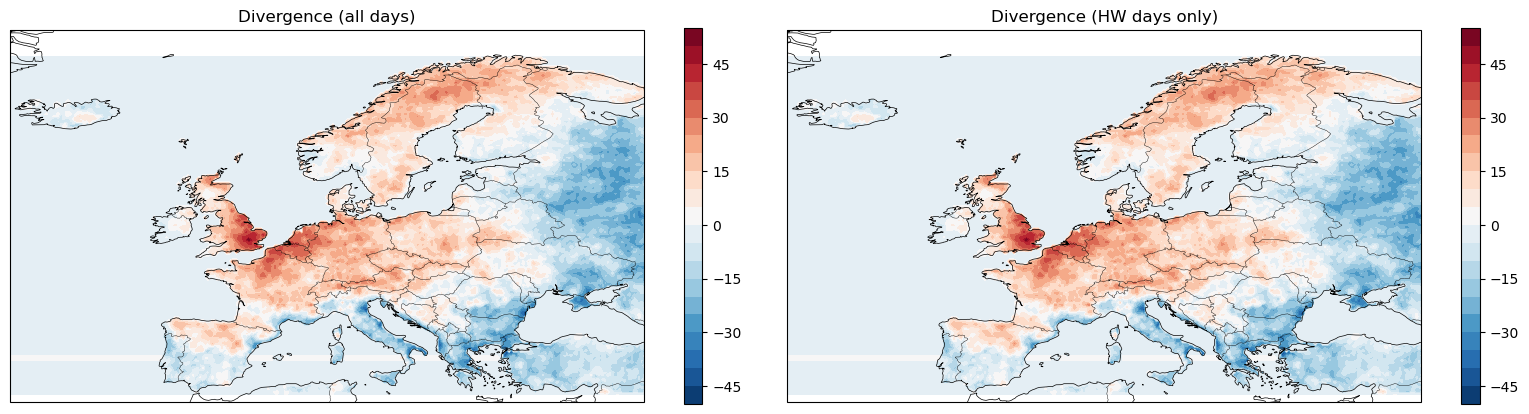

Saved divergence_map.png


In [7]:
# ── Divergence ──────────────────────────────────────────────────────────────
# there is ID (in-degree) and OD (out-degree)
# Wang et al. Eq. 3: divergence = OD - ID

divergence = clean_ds['OD'] - clean_ds['ID']   # xarray handles broadcasting
divergence.name = 'divergence'

# Add to dataset
clean_ds['divergence'] = divergence

# Climatological divergence map (single snapshot, like Wang et al. Fig 1)
# Option A: mean over all days
div_clim = divergence.mean(dim='time')

# Option B: mean over heatwave days only (more physically meaningful)
hw_mask = clean_ds['is_heatwave'].values.any(axis=(1, 2))  # (2790,) bool
div_hw = divergence.isel(time=hw_mask).mean(dim='time')

print(f"Divergence range (all days): "
      f"{float(div_clim.min()):.3f} to {float(div_clim.max()):.3f}")
print(f"Divergence range (HW days): "
      f"{float(div_hw.min()):.3f} to {float(div_hw.max()):.3f}")
print(f"Source nodes (div > 0): {(div_hw.values > 0).sum()}")
print(f"Sink nodes   (div < 0): {(div_hw.values < 0).sum()}")

# ── Quick plot to verify it looks physical ───────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5),
                          subplot_kw={'projection': ccrs.PlateCarree()})

for ax, data, title in zip(axes,
                            [div_clim, div_hw],
                            ['Divergence (all days)', 'Divergence (HW days only)']):
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
    ax.add_feature(cfeature.BORDERS, linewidth=0.3)
    im = ax.contourf(clean_ds.lon, clean_ds.lat, data,
                     levels=20, cmap='RdBu_r',
                     transform=ccrs.PlateCarree())
    plt.colorbar(im, ax=ax, shrink=0.8)
    ax.set_title(title)
    ax.set_extent([-25, 41, 35, 71])

plt.tight_layout()
plt.savefig('divergence_map.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved divergence_map.png")

## 2. Reshape into (years, days, lat, lon) for event extraction

In [8]:
# ── Extract coordinate arrays ────────────────────────────────────────────────
lat = clean_ds.lat.values    # (141,)
lon = clean_ds.lon.values    # (264,)
times = pd.DatetimeIndex(clean_ds.time.values)

# ── Verify time structure ────────────────────────────────────────────────────
years = times.year
months = times.month
print("Unique years:", np.unique(years))
print("Unique months:", np.unique(months))  # should be 6, 7, 8

days_per_year = pd.Series(years).value_counts().sort_index()
print("\nDays per year:")
print(days_per_year)
# Should be 92 for most years (June=30, July=31, Aug=31)
# 2790 / 30 = 93 — check if one year has 93 (leap year June has 30 days anyway)
# so 2790 = 30 * 93 is possible if some years have extra day

n_years = len(np.unique(years))
year_list = sorted(np.unique(years))
print(f"\nYears: {year_list[0]} to {year_list[-1]}, n={n_years}")

# ── Load key arrays into numpy ───────────────────────────────────────────────
# Only load what you need for event extraction (saves memory)
is_hw   = clean_ds['is_heatwave'].values.astype(bool)  # (2790, 141, 264)
z500    = clean_ds['z'].values                          # (2790, 141, 264)
div     = divergence.values                             # (2790, 141, 264)
od      = clean_ds['OD'].values                         # (2790, 141, 264)
id_     = clean_ds['ID'].values                         # (2790, 141, 264)
cc      = clean_ds['CC'].values                         # (2790, 141, 264)
swvl    = clean_ds['swvl1'].values                      # (2790, 141, 264)
land    = clean_ds['land_mask'].values                  # (2790, 141, 264)

print(f"\nArrays loaded. is_hw dtype: {is_hw.dtype}, z500 dtype: {z500.dtype}")
print(f"Memory: ~{(is_hw.nbytes + z500.nbytes + div.nbytes)*4 / 1e9:.1f} GB loaded")

Unique years: [1990 1991 1992 1993 1994 1995 1996 1997 1998 1999 2000 2001 2002 2003
 2004 2005 2006 2007 2008 2009 2010 2011 2012 2013 2014 2015 2016 2017
 2018 2019 2020]
Unique months: [6 7 8]

Days per year:
1990    92
1991    92
1992    92
1993    92
1994    92
1995    92
1996    92
1997    61
1998    92
1999    61
2000    92
2001    92
2002    92
2003    92
2004    92
2005    92
2006    92
2007    92
2008    92
2009    92
2010    92
2011    92
2012    92
2013    92
2014    92
2015    92
2016    92
2017    92
2018    92
2019    92
2020    92
Name: count, dtype: int64

Years: 1990 to 2020, n=31

Arrays loaded. is_hw dtype: bool, z500 dtype: float32
Memory: ~3.7 GB loaded


## Two months are missing from the CN source data: 
•	August 1997 
•	July 1999 


In [9]:
# Confirm exactly which months are present for 1997 and 1999
for yr in [1997, 1999]:
    yr_times = times[times.year == yr]
    print(f"\n{yr}: {len(yr_times)} days")
    print(f"  First: {yr_times[0].date()}")
    print(f"  Last:  {yr_times[-1].date()}")
    print(f"  Months present: {np.unique(yr_times.month)}")
    # Expected:
    # 1997: months [6, 7]     — August missing
    # 1999: months [6, 8]     — July missing


1997: 61 days
  First: 1997-06-01
  Last:  1997-07-31
  Months present: [6 7]

1999: 61 days
  First: 1999-06-01
  Last:  1999-08-31
  Months present: [6 8]


## Drop 1997 and 1999 entirely 

In [10]:
# ── Compute z500_anom and div_vals BEFORE applying the mask ─────────────────

# 1. Raw z500 in metres (convert from geopotential)
z500 = clean_ds['z'].values / 9.80665               # (2790, 141, 264)

# 2. Z500 anomaly = remove climatological mean at each grid cell
z500_clim    = z500.mean(axis=0)                    # (141, 264)
z500_anom    = z500 - z500_clim                     # (2790, 141, 264)

# 3. Divergence = OD - ID
div_vals     = clean_ds['OD'].values - clean_ds['ID'].values  # (2790, 141, 264)

# ── Now apply the mask ───────────────────────────────────────────────────────
times        = pd.DatetimeIndex(clean_ds.time.values)
is_hw        = clean_ds['is_heatwave'].values.astype(bool)

years_to_drop = [1997, 1999]
keep_mask     = ~np.isin(times.year, years_to_drop)

times_clean     = times[keep_mask]
is_hw_clean     = is_hw[keep_mask]
z500_clean      = z500[keep_mask]
z500_anom_clean = z500_anom[keep_mask]
div_clean       = div_vals[keep_mask]
swvl_clean      = clean_ds['swvl1'].values[keep_mask]
u_clean         = clean_ds['u'].values[keep_mask]
v_clean         = clean_ds['v'].values[keep_mask]
cc_clean        = clean_ds['CC'].values[keep_mask]
od_clean        = clean_ds['OD'].values[keep_mask]
id_clean        = clean_ds['ID'].values[keep_mask]
land_clean      = clean_ds['land_mask'].values[keep_mask]

# ── Verify ───────────────────────────────────────────────────────────────────
year_counts = pd.Series(times_clean.year).value_counts().sort_index()
print("Days per year after fix:")
print(year_counts)

print(f"\nTotal days:  {len(times_clean)}")
print(f"Years:       {len(np.unique(times_clean.year))}")
print(f"29 × 92 =    {29 * 92}")

# Recompute divergence maps on clean data
hw_any_day_clean = is_hw_clean.any(axis=(1, 2))
div_clim_clean   = div_clean.mean(axis=0)
div_hw_clean     = div_clean[hw_any_day_clean].mean(axis=0)

print(f"\nHW days in clean data: {hw_any_day_clean.sum()}")
print(f"Divergence (clean, HW days): "
      f"{div_hw_clean.min():.3f} to {div_hw_clean.max():.3f}")

# Memory check
total_bytes = sum(a.nbytes for a in [
    is_hw_clean, z500_clean, z500_anom_clean,
    div_clean, swvl_clean, u_clean, v_clean,
    cc_clean, od_clean, id_clean
])
print(f"\nTotal memory (clean arrays): {total_bytes / 1e9:.2f} GB")

# Quick sanity check on z500_anom
print(f"\nZ500 (m) range:       {z500_clean.min():.0f} to {z500_clean.max():.0f}")
print(f"Z500 anomaly range:   {z500_anom_clean.min():.1f} to "
      f"{z500_anom_clean.max():.1f}")
print(f"Z500 anomaly mean:    {z500_anom_clean.mean():.4f}  ← should be ~0")

Days per year after fix:
1990    92
1991    92
1992    92
1993    92
1994    92
1995    92
1996    92
1998    92
2000    92
2001    92
2002    92
2003    92
2004    92
2005    92
2006    92
2007    92
2008    92
2009    92
2010    92
2011    92
2012    92
2013    92
2014    92
2015    92
2016    92
2017    92
2018    92
2019    92
2020    92
Name: count, dtype: int64

Total days:  2668
Years:       29
29 × 92 =    2668

HW days in clean data: 2665
Divergence (clean, HW days): -49.804 to 55.945

Total memory (clean arrays): 3.67 GB

Z500 (m) range:       5152 to 5997
Z500 anomaly range:   -667.1 to 397.2
Z500 anomaly mean:    0.2994  ← should be ~0


## 3. Event Extraction

In [11]:
def haversine_matrix(center_lat, center_lon, lat_grid, lon_grid):
    """Vectorized Haversine distance from one point to all grid cells."""
    dlat = np.radians(lat_grid - center_lat)
    dlon = np.radians(lon_grid - center_lon)
    a = (np.sin(dlat/2)**2 +
         np.cos(np.radians(center_lat)) *
         np.cos(np.radians(lat_grid)) *
         np.sin(dlon/2)**2)
    return 6371 * 2 * np.arcsin(np.sqrt(np.clip(a, 0, 1)))

In [12]:
from scipy.ndimage import label as scipy_label

def find_largest_component_size(hw_slice):
    """
    Returns the size (cell count) of the largest 
    connected heatwave component on a single day.
    """
    labeled, n_features = scipy_label(hw_slice)
    if n_features == 0:
        return 0, None
    sizes = np.bincount(labeled.ravel())[1:]  # exclude background (0)
    largest_idx = sizes.argmax() + 1
    largest_size = sizes.max()
    return largest_size, labeled == largest_idx


def extract_events_v2(is_hw, z500_anom, times, lat, lon,
                      min_duration=3,
                      min_component_size=200):   # ← key parameter
    """
    Event = period where the LARGEST connected HW component 
    exceeds min_component_size cells continuously for min_duration days.
    
    At 0.25 deg, 200 cells ≈ 200 × (0.25 deg)^2 ≈ ~125,000 km^2
    roughly the size of a country (e.g. Greece, Hungary)
    Adjust min_component_size to get physically meaningful events.
    """
    lat_grid, lon_grid = np.meshgrid(lat, lon, indexing='ij')
    year_list = sorted(np.unique(times.year))
    events    = []

    for yr in year_list:
        yr_mask = times.year == yr
        yr_idx  = np.where(yr_mask)[0]
        hw_yr   = is_hw[yr_mask]        # (92, 141, 264)
        z500_yr = z500_anom[yr_mask]    # (92, 141, 264)
        n_days  = len(yr_idx)

        # Daily largest component size
        daily_max_size = np.array([
            find_largest_component_size(hw_yr[t])[0]
            for t in range(n_days)
        ])

        # Event = contiguous days where largest component > threshold
        hw_active = daily_max_size >= min_component_size

        t = 0
        while t < n_days:
            if not hw_active[t]:
                t += 1
                continue

            t_start = t
            while t < n_days and hw_active[t]:
                t += 1
            t_end    = t
            duration = t_end - t_start

            if duration < min_duration:
                continue

            # Peak day = day with largest component
            peak_day = t_start + daily_max_size[t_start:t_end].argmax()
            peak_size = int(daily_max_size[peak_day])

            # Track Z500 center for up to 10 days from onset
            track_len = min(10, n_days - t_start)
            centers   = []
            cur_lat, cur_lon = None, None

            for dt in range(track_len):
                z_t  = z500_yr[t_start + dt]
                hw_t = hw_yr[t_start + dt]

                if dt == 0:
                    masked = np.where(hw_t, z_t, -np.inf)
                    if masked.max() == -np.inf:
                        masked = z_t
                    idx = np.unravel_index(masked.argmax(), masked.shape)
                else:
                    dist   = haversine_matrix(cur_lat, cur_lon,
                                              lat_grid, lon_grid)
                    search = np.where(dist < 1000, z_t, -np.inf)
                    if search.max() == -np.inf:
                        search = z_t
                    idx = np.unravel_index(search.argmax(), search.shape)

                cur_lat = lat[idx[0]]
                cur_lon = lon[idx[1]]
                centers.append([cur_lat, cur_lon])

            events.append({
                'year':         yr,
                'global_start': int(yr_idx[t_start]),
                'global_end':   int(yr_idx[t_end - 1]),
                'duration':     duration,
                'peak_size':    peak_size,
                'centers':      np.array(centers),
            })

    # Summary
    durations = [e['duration'] for e in events]
    sizes     = [e['peak_size'] for e in events]
    print(f"Total events:       {len(events)}")
    print(f"Events per summer:  {len(events)/len(year_list):.1f}")
    print(f"Duration — min: {min(durations)}  max: {max(durations)}  "
          f"mean: {np.mean(durations):.1f} days")
    print(f"Peak size — min: {min(sizes)}  max: {max(sizes)}  "
          f"mean: {np.mean(sizes):.0f} cells")
    print("\nEvents per year:")
    for yr in year_list:
        evs = [e for e in events if e['year'] == yr]
        marker = " ← case study" if yr in [2003, 2010, 2018] else ""
        print(f"  {yr}: {len(evs)}{marker}")

    return events


# ── Try three thresholds to find the right one ───────────────────────────────
for threshold in [500, 1000, 2000]:
    print(f"\n{'='*50}")
    print(f"Threshold: {threshold} cells")
    print(f"{'='*50}")
    events_test = extract_events_v2(
        is_hw_clean, z500_anom_clean,
        times_clean, lat, lon,
        min_duration=3,
        min_component_size=threshold
    )


Threshold: 500 cells
Total events:       165
Events per summer:  5.7
Duration — min: 3  max: 58  mean: 10.0 days
Peak size — min: 539  max: 7279  mean: 2487 cells

Events per year:
  1990: 8
  1991: 7
  1992: 6
  1993: 7
  1994: 3
  1995: 8
  1996: 5
  1998: 5
  2000: 7
  2001: 7
  2002: 4
  2003: 6 ← case study
  2004: 6
  2005: 7
  2006: 2
  2007: 5
  2008: 6
  2009: 7
  2010: 4 ← case study
  2011: 7
  2012: 4
  2013: 7
  2014: 4
  2015: 6
  2016: 7
  2017: 7
  2018: 4 ← case study
  2019: 4
  2020: 5

Threshold: 1000 cells
Total events:       145
Events per summer:  5.0
Duration — min: 3  max: 49  mean: 8.1 days
Peak size — min: 1139  max: 7279  mean: 2947 cells

Events per year:
  1990: 6
  1991: 4
  1992: 7
  1993: 3
  1994: 4
  1995: 6
  1996: 5
  1998: 3
  2000: 7
  2001: 5
  2002: 5
  2003: 6 ← case study
  2004: 3
  2005: 7
  2006: 7
  2007: 7
  2008: 5
  2009: 6
  2010: 3 ← case study
  2011: 6
  2012: 4
  2013: 6
  2014: 3
  2015: 6
  2016: 5
  2017: 6
  2018: 5 ← case stu

Reasons to choose 1000:

    No years with |zero events (2000 cells drops 1991, 1993, 2004)
    5 events/summer is physically realistic for European JJA
    8 day mean duration is consistent with literature (heatwaves typically 5–14 days)
    1000 cells at 0.25° ≈ ~625,000 km² ≈ roughly France-sized — a meaningful synoptic-scale event
    500 cells gives 58-day events which are suspiciously long — likely merging separate events


## 4. Finalise events and label propagating/standing

Total events:       145
Events per summer:  5.0
Duration — min: 3  max: 49  mean: 8.1 days
Peak size — min: 1139  max: 7279  mean: 2947 cells

Events per year:
  1990: 6
  1991: 4
  1992: 7
  1993: 3
  1994: 4
  1995: 6
  1996: 5
  1998: 3
  2000: 7
  2001: 5
  2002: 5
  2003: 6 ← case study
  2004: 3
  2005: 7
  2006: 7
  2007: 7
  2008: 5
  2009: 6
  2010: 3 ← case study
  2011: 6
  2012: 4
  2013: 6
  2014: 3
  2015: 6
  2016: 5
  2017: 6
  2018: 5 ← case study
  2019: 3
  2020: 2

Finalised: 145 events across 29 summers

=== Propagating vs Standing ===
Propagating: 128  (88%)
Standing:    17  (12%)

Displacement statistics:
  Propagating — mean: 1832 km  max: 4925 km
  Standing    — mean: 890 km  max: 2041 km

Case study events:
  2003  dur=13d  disp=1238 km  peak=4356 cells  → PROPAGATING
  2003  dur=7d  disp=1782 km  peak=2374 cells  → PROPAGATING
  2003  dur=4d  disp=674 km  peak=1674 cells  → PROPAGATING
  2003  dur=35d  disp=3040 km  peak=4671 cells  → PROPAGATING
  2003  dur=

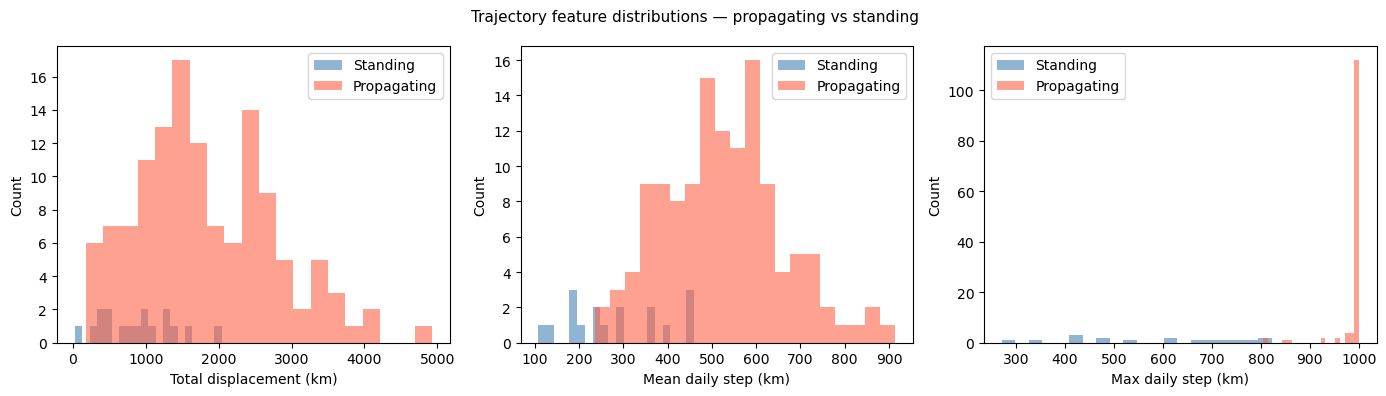

Saved: propagating_standing_features.png


In [13]:
# ── Finalise with threshold 1000 ────────────────────────────────────────────
events = extract_events_v2(
    is_hw_clean, z500_anom_clean,
    times_clean, lat, lon,
    min_duration=3,
    min_component_size=1000
)

print(f"\nFinalised: {len(events)} events across 29 summers")

# ── Label propagating vs standing ────────────────────────────────────────────
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

def haversine(p1, p2):
    dlat = np.radians(p2[0] - p1[0])
    dlon = np.radians(p2[1] - p1[1])
    a    = (np.sin(dlat/2)**2 +
            np.cos(np.radians(p1[0])) *
            np.cos(np.radians(p2[0])) *
            np.sin(dlon/2)**2)
    return 6371 * 2 * np.arcsin(np.sqrt(np.clip(a, 0, 1)))


def label_events(events):
    feats = []
    for ev in events:
        c = ev['centers']
        if len(c) < 2:
            feats.append([0., 0., 0.])
            continue
        total     = haversine(c[0], c[-1])
        steps     = [haversine(c[i], c[i+1]) for i in range(len(c)-1)]
        mean_step = np.mean(steps)
        max_step  = np.max(steps)
        feats.append([total, mean_step, max_step])

    feats = np.array(feats)
    X     = StandardScaler().fit_transform(feats)
    km    = KMeans(n_clusters=2, random_state=42, n_init=10)
    labs  = km.fit_predict(X)

    # Ensure label 1 = propagating (higher total displacement)
    if feats[labs == 0, 0].mean() > feats[labs == 1, 0].mean():
        labs = 1 - labs

    for ev, lab in zip(events, labs):
        ev['label'] = int(lab)

    # ── Summary ──────────────────────────────────────────────────────────────
    prop  = (labs == 1).sum()
    stand = (labs == 0).sum()
    print(f"\n=== Propagating vs Standing ===")
    print(f"Propagating: {prop}  ({100*prop/len(labs):.0f}%)")
    print(f"Standing:    {stand}  ({100*stand/len(labs):.0f}%)")
    print(f"\nDisplacement statistics:")
    print(f"  Propagating — mean: {feats[labs==1,0].mean():.0f} km  "
          f"max: {feats[labs==1,0].max():.0f} km")
    print(f"  Standing    — mean: {feats[labs==0,0].mean():.0f} km  "
          f"max: {feats[labs==0,0].max():.0f} km")

    # ── Case study check ─────────────────────────────────────────────────────
    print(f"\nCase study events:")
    for ev in events:
        if ev['year'] in [2003, 2010, 2018]:
            tag  = 'PROPAGATING' if ev['label'] == 1 else 'STANDING'
            disp = feats[events.index(ev), 0]
            print(f"  {ev['year']}  dur={ev['duration']}d  "
                  f"disp={disp:.0f} km  peak={ev['peak_size']} cells"
                  f"  → {tag}")

    return events, labs, feats


events, labels, traj_feats = label_events(events)

# ── Build daily label array ───────────────────────────────────────────────────
daily_labels = np.full(len(times_clean), -1, dtype=np.int8)
for ev in events:
    daily_labels[ev['global_start']:ev['global_end'] + 1] = ev['label']

print(f"\n=== Daily label array ===")
print(f"Standing days:    {(daily_labels == 0).sum()}")
print(f"Propagating days: {(daily_labels == 1).sum()}")
print(f"No-event days:    {(daily_labels ==-1).sum()}")
print(f"Total:            {len(daily_labels)}")

# ── Quick visualisation of trajectory features ───────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

feature_names = ['Total displacement (km)', 
                 'Mean daily step (km)', 
                 'Max daily step (km)']
colors = ['steelblue' if l == 0 else 'tomato' for l in labels]

for ax, feat_idx, name in zip(axes, range(3), feature_names):
    prop_vals  = traj_feats[labels == 1, feat_idx]
    stand_vals = traj_feats[labels == 0, feat_idx]
    ax.hist(stand_vals, bins=20, alpha=0.6, 
            color='steelblue', label='Standing')
    ax.hist(prop_vals,  bins=20, alpha=0.6, 
            color='tomato',    label='Propagating')
    ax.set_xlabel(name)
    ax.set_ylabel('Count')
    ax.legend()

plt.suptitle('Trajectory feature distributions — propagating vs standing',
             fontsize=11)
plt.tight_layout()
plt.savefig('propagating_standing_features.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: propagating_standing_features.png")

In [14]:
def extract_events_v3(is_hw, z500_anom, times, lat, lon,
                      min_duration=3,
                      min_component_size=1000,
                      search_radius_km=500):      # ← reduced from 1000
    
    lat_grid, lon_grid = np.meshgrid(lat, lon, indexing='ij')
    year_list = sorted(np.unique(times.year))
    events    = []

    for yr in year_list:
        yr_mask = times.year == yr
        yr_idx  = np.where(yr_mask)[0]
        hw_yr   = is_hw[yr_mask]
        z500_yr = z500_anom[yr_mask]
        n_days  = len(yr_idx)

        daily_max_size = np.array([
            find_largest_component_size(hw_yr[t])[0]
            for t in range(n_days)
        ])
        hw_active = daily_max_size >= min_component_size

        t = 0
        while t < n_days:
            if not hw_active[t]:
                t += 1
                continue

            t_start = t
            while t < n_days and hw_active[t]:
                t += 1
            t_end    = t
            duration = t_end - t_start

            if duration < min_duration:
                continue

            peak_day  = t_start + daily_max_size[t_start:t_end].argmax()
            peak_size = int(daily_max_size[peak_day])

            # Track for up to 10 days with REDUCED search radius
            track_len = min(10, n_days - t_start)
            centers   = []
            cur_lat, cur_lon = None, None

            for dt in range(track_len):
                z_t  = z500_yr[t_start + dt]
                hw_t = hw_yr[t_start + dt]

                if dt == 0:
                    masked = np.where(hw_t, z_t, -np.inf)
                    if masked.max() == -np.inf:
                        masked = z_t
                    idx = np.unravel_index(masked.argmax(), masked.shape)
                else:
                    dist   = haversine_matrix(cur_lat, cur_lon,
                                              lat_grid, lon_grid)
                    search = np.where(dist < search_radius_km, z_t, -np.inf)
                    if search.max() == -np.inf:
                        # Fallback: expand to 800 km if nothing found
                        search = np.where(dist < 800, z_t, -np.inf)
                    if search.max() == -np.inf:
                        search = z_t
                    idx = np.unravel_index(search.argmax(), search.shape)

                cur_lat = lat[idx[0]]
                cur_lon = lon[idx[1]]
                centers.append([cur_lat, cur_lon])

            events.append({
                'year':         yr,
                'global_start': int(yr_idx[t_start]),
                'global_end':   int(yr_idx[t_end - 1]),
                'duration':     duration,
                'peak_size':    peak_size,
                'centers':      np.array(centers),
            })

    durations = [e['duration'] for e in events]
    print(f"Total events:      {len(events)}")
    print(f"Events per summer: {len(events)/len(year_list):.1f}")
    print(f"Duration — min: {min(durations)}  "
          f"max: {max(durations)}  "
          f"mean: {np.mean(durations):.1f} days")
    return events


def label_events_v2(events):
    """
    Uses displacement per day (speed) instead of total displacement.
    This correctly penalises slow long-duration events (standing).
    """
    def haversine(p1, p2):
        dlat = np.radians(p2[0] - p1[0])
        dlon = np.radians(p2[1] - p1[1])
        a    = (np.sin(dlat/2)**2 +
                np.cos(np.radians(p1[0])) *
                np.cos(np.radians(p2[0])) *
                np.sin(dlon/2)**2)
        return 6371 * 2 * np.arcsin(np.sqrt(np.clip(a, 0, 1)))

    feats = []
    for ev in events:
        c        = ev['centers']
        duration = ev['duration']

        if len(c) < 2:
            feats.append([0., 0., 0., duration])
            continue

        total     = haversine(c[0], c[-1])
        steps     = [haversine(c[i], c[i+1]) for i in range(len(c)-1)]
        mean_step = np.mean(steps)

        # Key new feature: displacement per day of event duration
        # Standing events: large duration, moderate displacement → low speed
        # Propagating events: large displacement in short time → high speed
        speed = total / duration

        feats.append([total, mean_step, speed, duration])

    feats = np.array(feats)

    # Use total displacement + speed + duration for clustering
    X = StandardScaler().fit_transform(feats[:, [0, 2, 3]])
    km    = KMeans(n_clusters=2, random_state=42, n_init=10)
    labs  = km.fit_predict(X)

    # Label 1 = propagating = higher speed
    if feats[labs==0, 2].mean() > feats[labs==1, 2].mean():
        labs = 1 - labs

    for ev, lab in zip(events, labs):
        ev['label'] = int(lab)

    prop  = (labs == 1).sum()
    stand = (labs == 0).sum()
    print(f"\n=== Propagating vs Standing ===")
    print(f"Propagating: {prop}  ({100*prop/len(labs):.0f}%)")
    print(f"Standing:    {stand}  ({100*stand/len(labs):.0f}%)")
    print(f"\nFeature statistics:")
    print(f"  Propagating — total disp: {feats[labs==1,0].mean():.0f} km  "
          f"speed: {feats[labs==1,2].mean():.0f} km/day  "
          f"mean dur: {feats[labs==1,3].mean():.1f} days")
    print(f"  Standing    — total disp: {feats[labs==0,0].mean():.0f} km  "
          f"speed: {feats[labs==0,2].mean():.0f} km/day  "
          f"mean dur: {feats[labs==0,3].mean():.1f} days")

    print(f"\nCase study events:")
    for ev in events:
        if ev['year'] in [2003, 2010, 2018]:
            tag  = 'PROPAGATING' if ev['label'] == 1 else 'STANDING'
            idx  = events.index(ev)
            print(f"  {ev['year']}  dur={ev['duration']}d  "
                  f"disp={feats[idx,0]:.0f} km  "
                  f"speed={feats[idx,2]:.0f} km/day  "
                  f"→ {tag}")

    return events, labs, feats


# Run with reduced search radius
events = extract_events_v3(
    is_hw_clean, z500_anom_clean,
    times_clean, lat, lon,
    min_component_size=1000,
    search_radius_km=500
)

events, labels, traj_feats = label_events_v2(events)

Total events:      145
Events per summer: 5.0
Duration — min: 3  max: 49  mean: 8.1 days

=== Propagating vs Standing ===
Propagating: 43  (30%)
Standing:    102  (70%)

Feature statistics:
  Propagating — total disp: 2201 km  speed: 531 km/day  mean dur: 4.8 days
  Standing    — total disp: 1075 km  speed: 153 km/day  mean dur: 9.5 days

Case study events:
  2003  dur=13d  disp=723 km  speed=56 km/day  → STANDING
  2003  dur=7d  disp=1782 km  speed=255 km/day  → STANDING
  2003  dur=4d  disp=674 km  speed=168 km/day  → STANDING
  2003  dur=35d  disp=1971 km  speed=56 km/day  → STANDING
  2003  dur=3d  disp=1619 km  speed=540 km/day  → PROPAGATING
  2003  dur=5d  disp=1690 km  speed=338 km/day  → PROPAGATING
  2010  dur=6d  disp=2030 km  speed=338 km/day  → PROPAGATING
  2010  dur=4d  disp=2989 km  speed=747 km/day  → PROPAGATING
  2010  dur=49d  disp=2387 km  speed=49 km/day  → STANDING
  2018  dur=3d  disp=324 km  speed=108 km/day  → STANDING
  2018  dur=12d  disp=1857 km  speed=155 

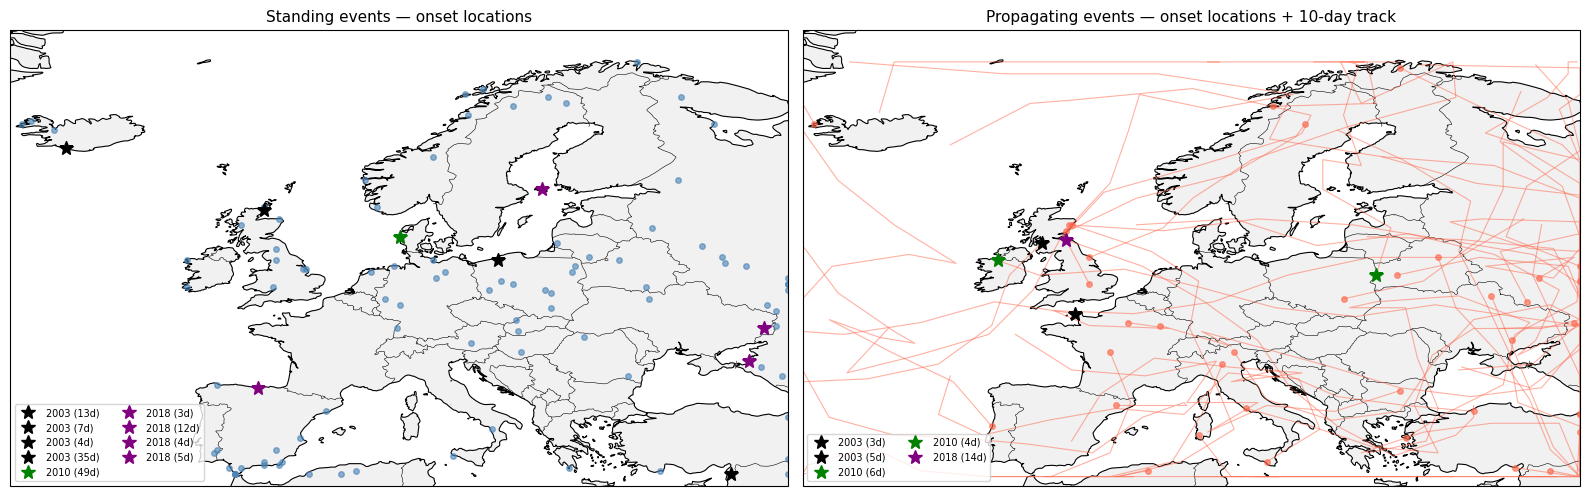

Saved: event_onset_map.png

=== Daily label array ===
Standing days:    964
Propagating days: 205
No-event days:    1499
Total:            2668

Class ratio (HW days only): 205 prop / 964 stand = 0.21x


In [15]:

fig, axes = plt.subplots(1, 2, figsize=(16, 5),
                          subplot_kw={'projection': ccrs.PlateCarree()})

titles = ['Standing events — onset locations',
          'Propagating events — onset locations + 10-day track']

for ax, title in zip(axes, titles):
    ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
    ax.add_feature(cfeature.BORDERS,   linewidth=0.4)
    ax.add_feature(cfeature.LAND,      facecolor='lightgray', alpha=0.3)
    ax.set_extent([-25, 41, 35, 71])
    ax.set_title(title, fontsize=11)

for ev in events:
    c   = ev['centers']
    col = 'tomato' if ev['label'] == 1 else 'steelblue'
    ax  = axes[ev['label']]  # standing → ax[0], propagating → ax[1]

    # Onset point
    ax.plot(c[0, 1], c[0, 0], 'o', color=col, markersize=4,
            alpha=0.6, transform=ccrs.PlateCarree())

    # Track line (propagating only)
    if ev['label'] == 1 and len(c) > 1:
        ax.plot(c[:, 1], c[:, 0], '-', color=col,
                linewidth=0.8, alpha=0.5,
                transform=ccrs.PlateCarree())

# Mark case study onset points
case_colors = {2003: 'black', 2010: 'green', 2018: 'purple'}
for ev in events:
    if ev['year'] in case_colors:
        c   = ev['centers']
        col = case_colors[ev['year']]
        ax  = axes[ev['label']]
        ax.plot(c[0, 1], c[0, 0], '*', color=col, markersize=10,
                transform=ccrs.PlateCarree(),
                label=f"{ev['year']} ({ev['duration']}d)")

for ax in axes:
    handles, lbls = ax.get_legend_handles_labels()
    if handles:
        ax.legend(loc='lower left', fontsize=7, ncol=2)

plt.tight_layout()
plt.savefig('event_onset_map.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: event_onset_map.png")

# ── Also build and print the daily label array ───────────────────────────────
daily_labels = np.full(len(times_clean), -1, dtype=np.int8)
for ev in events:
    daily_labels[ev['global_start']:ev['global_end'] + 1] = ev['label']

print(f"\n=== Daily label array ===")
print(f"Standing days:    {(daily_labels == 0).sum()}")
print(f"Propagating days: {(daily_labels == 1).sum()}")
print(f"No-event days:    {(daily_labels ==-1).sum()}")
print(f"Total:            {len(daily_labels)}")
print(f"\nClass ratio (HW days only): "
      f"{(daily_labels==1).sum()} prop / "
      f"{(daily_labels==0).sum()} stand = "
      f"{(daily_labels==1).sum()/(daily_labels==0).sum():.2f}x")

## 5. Heatwave propagation pathway analysis

Propagating events with full tracks: 43


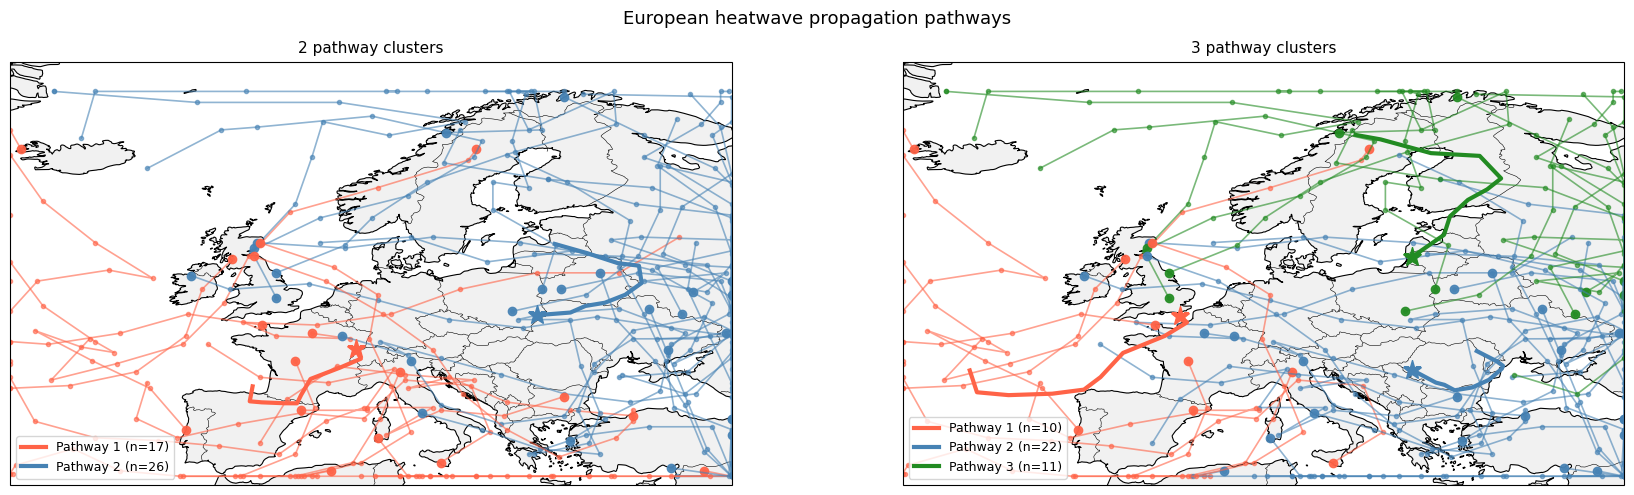

Saved: heatwave_pathways.png


In [16]:
from scipy.interpolate import interp1d
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler


def extract_pathway_features(events, n_points=10):
    """
    Interpolates each propagating event centroid track to n_points
    so all tracks have equal length for clustering.
    Returns (features, valid_events) where features is (n_prop, n_points*2).
    """
    prop_events = [ev for ev in events if ev['label'] == 1]
    features, valid_events = [], []

    for ev in prop_events:
        c = ev['centers']
        if len(c) < 3:
            continue
        t_orig     = np.linspace(0, 1, len(c))
        t_new      = np.linspace(0, 1, n_points)
        lat_interp = interp1d(t_orig, c[:, 0], kind='linear')(t_new)
        lon_interp = interp1d(t_orig, c[:, 1], kind='linear')(t_new)
        features.append(np.concatenate([lat_interp, lon_interp]))
        valid_events.append(ev)

    return np.array(features), valid_events


features, prop_events = extract_pathway_features(events, n_points=10)
print(f"Propagating events with full tracks: {len(prop_events)}")

cluster_colors = ['tomato', 'steelblue', 'forestgreen']

fig, axes = plt.subplots(1, 2, figsize=(18, 5),
                          subplot_kw={'projection': ccrs.PlateCarree()})

for ax, n_clusters in zip(axes, [2, 3]):
    X_scaled       = StandardScaler().fit_transform(features)
    km             = KMeans(n_clusters=n_clusters, random_state=42, n_init=20)
    pathway_labels = km.fit_predict(X_scaled)

    ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
    ax.add_feature(cfeature.BORDERS,   linewidth=0.4)
    ax.add_feature(cfeature.LAND,      facecolor='lightgray', alpha=0.3)
    ax.set_extent([-25, 41, 35, 71])
    ax.set_title(f'{n_clusters} pathway clusters', fontsize=11)

    for ev, lab in zip(prop_events, pathway_labels):
        c   = ev['centers']
        col = cluster_colors[lab]
        ax.plot(c[:, 1], c[:, 0], '-o', color=col, linewidth=1.2,
                markersize=3, alpha=0.6, transform=ccrs.PlateCarree())
        ax.plot(c[0, 1], c[0, 0], 'o', color=col, markersize=6,
                alpha=0.9, transform=ccrs.PlateCarree())

    for k in range(n_clusters):
        mask     = pathway_labels == k
        mean_f   = features[mask].mean(axis=0)
        mean_lat = mean_f[:10]
        mean_lon = mean_f[10:]
        ax.plot(mean_lon, mean_lat, '-', color=cluster_colors[k],
                linewidth=3, transform=ccrs.PlateCarree(),
                label=f'Pathway {k+1} (n={mask.sum()})')
        ax.plot(mean_lon[0], mean_lat[0], '*', color=cluster_colors[k],
                markersize=14, transform=ccrs.PlateCarree())

    ax.legend(loc='lower left', fontsize=9)

plt.suptitle('European heatwave propagation pathways', fontsize=13)
plt.tight_layout()
plt.savefig('heatwave_pathways.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: heatwave_pathways.png")

In [17]:
# Check for suspiciously fast-moving events in prop_events
for ev in prop_events:
    c = ev['centers']
    if len(c) >= 2:
        dists = [np.sqrt((c[i+1,0]-c[i,0])**2 + (c[i+1,1]-c[i,1])**2) 
                 for i in range(len(c)-1)]
        if max(dists) > 20:   # >20 degrees per day = suspicious
            print(f"  year={ev['year']}  dur={ev['duration']}d  "
                  f"max_jump={max(dists):.1f}°  speed={ev['speed']:.0f} km/day")

## 6. Build sequences

In [18]:
def choose_coefficients_and_target(ds, coeffs, target):
    return xr.concat([ds[coeff] for coeff in coeffs], dim="channel").assign_coords(channel=list(coeffs)), ds[target]


In [19]:
class LazySeqDataset(Dataset):
    """
    Reads sequences on-the-fly from pre-transposed numpy arrays.
    Never builds the full (N, L, C, H, W) array in memory.
    """
    def __init__(self, Xt_vals, yt_vals, labels, times, seq_len=14):
        """
        Xt_vals : (T, C, H, W) float32 numpy — full time series
        yt_vals : (T, H, W)    float32 numpy — CC targets
        labels  : (T,)         int8    numpy — prop/standing labels
        times   : pd.DatetimeIndex
        seq_len : int
        """
        self.Xt     = Xt_vals
        self.yt     = yt_vals
        self.labels = labels
        self.times  = times
        self.seq_len = seq_len

        # Build index: list of (start_idx, end_idx) per year, no cross-year
        self.indices = []
        for yr in np.unique(times.year):
            yr_idx = np.where(times.year == yr)[0]
            T = len(yr_idx)
            if T <= seq_len:
                continue
            for i in range(T - seq_len):
                self.indices.append((yr_idx[i], yr_idx[i + seq_len]))

        print(f"LazySeqDataset: {len(self.indices)} sequences")

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        start, target = self.indices[idx]
        X = torch.from_numpy(
            self.Xt[start:start + self.seq_len].copy()
        ).float()                                      # (L, C, H, W)
        y = torch.from_numpy(
            self.yt[target][None].copy()
        ).float()                                      # (1, H, W)
        yp = int(self.labels[target])                  # scalar

        return {"X": X, "y": y, "y_prop": torch.tensor(yp, dtype=torch.long)}

## 7. Train/val split

In [20]:
labels_aligned = daily_labels[:-1]
times_aligned  = pd.DatetimeIndex(times_clean[:-1])

COEFFS = ["BC", "DC", "ID", "OD", "is_heatwave",
          "swvl1", "land_mask", "u", "v", "z"]
TARGET = "CC"

clean_years       = [yr for yr in range(1990, 2021) if yr not in [1997, 1999]]
clean_ds_filtered = clean_ds.sel(time=clean_ds.time.dt.year.isin(clean_years))

X_xr, y_xr   = choose_coefficients_and_target(clean_ds_filtered, COEFFS, TARGET)
y_xr          = y_xr.shift(time=-1)
X_xr_trim     = X_xr.isel(time=slice(None, -1))
y_xr_trim     = y_xr.isel(time=slice(None, -1))

# ================================
# SAVE FULL PROCESSED DATASET
# ================================

full_ready_ds = clean_ds.copy()

# optional: also save the training-ready target/label
full_ready_ds["CC_target_next_day"] = y_xr_trim.astype("float32")

labels_aligned_da = xr.DataArray(
    labels_aligned,
    dims=["time"],
    coords={"time": X_xr_trim.time},
    name="event_label"
)

full_ready_ds["event_label"] = labels_aligned_da.astype("int8")

# IMPORTANT: align full dataset to the same final time range
full_ready_ds = full_ready_ds.sel(time=X_xr_trim.time)

encoding = {
    var: {"zlib": True, "complevel": 4}
    for var in full_ready_ds.data_vars
}

full_ready_ds.to_netcdf(
    "full_processed_training_dataset.nc",
    format="NETCDF4",
    engine="netcdf4",
    encoding=encoding
)

print("Saved full_processed_training_dataset.nc")
print(full_ready_ds)


# ── Materialise only (T, C, H, W) and (T, H, W) — manageable ────────────────
print("Transposing X... ", end="")
Xt_vals = X_xr_trim.transpose("time","channel","lat","lon").values.astype(np.float32)
print(f"done  {Xt_vals.nbytes/1e9:.2f} GB")

print("Loading y...     ", end="")
yt_vals = y_xr_trim.transpose("time","lat","lon").values.astype(np.float32)
print(f"done  {yt_vals.nbytes/1e9:.2f} GB")

# ── Train/val split on time axis ─────────────────────────────────────────────
val_years   = [2016, 2017, 2018, 2019, 2020]
val_tmask   = times_aligned.year.isin(val_years)
train_tmask = ~val_tmask

Xt_tr,  Xt_val  = Xt_vals[train_tmask],  Xt_vals[val_tmask]
yt_tr,  yt_val  = yt_vals[train_tmask],  yt_vals[val_tmask]
lbl_tr, lbl_val = labels_aligned[train_tmask], labels_aligned[val_tmask]
tms_tr, tms_val = times_aligned[train_tmask],  times_aligned[val_tmask]

print(f"\nTrain: {len(tms_tr)} days  ({tms_tr.year.min()}–{tms_tr.year.max()})")
print(f"Val:   {len(tms_val)} days  ({tms_val.year.min()}–{tms_val.year.max()})")

prop_pos_weight = float((lbl_tr == 0).sum()) / max(float((lbl_tr == 1).sum()), 1)
print(f"prop_pos_weight: {prop_pos_weight:.2f}")

# ── Lazy datasets + dataloaders ───────────────────────────────────────────────
seq_len      = 14
train_ds     = LazySeqDataset(Xt_tr,  yt_tr,  lbl_tr, tms_tr,  seq_len)
val_ds       = LazySeqDataset(Xt_val, yt_val, lbl_val, tms_val, seq_len)

train_loader = DataLoader(train_ds, batch_size=4, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=4, shuffle=False, num_workers=0)

print(f"\nTrain sequences: {len(train_ds)}")
print(f"Val   sequences: {len(val_ds)}")

# ── Sanity check one batch ────────────────────────────────────────────────────
batch = next(iter(train_loader))
print(f"\nbatch['X']:      {batch['X'].shape}   ← expect (4, 14, 10, 141, 264)")
print(f"batch['y']:      {batch['y'].shape}   ← expect (4, 1, 141, 264)")
print(f"batch['y_prop']: {batch['y_prop']}    ← expect 4 values of -1/0/1")

Saved full_processed_training_dataset.nc
<xarray.Dataset> Size: 5GB
Dimensions:             (lon: 264, lat: 141, time: 2667)
Coordinates:
  * lon                 (lon) float32 1kB -25.0 -24.75 -24.49 ... 40.75 41.0
  * lat                 (lat) float32 564B 35.8 36.05 36.3 ... 70.5 70.75 71.0
  * time                (time) datetime64[ns] 21kB 1990-06-01 ... 2020-08-30
Data variables: (12/14)
    DC                  (time, lat, lon) float32 397MB 0.0 0.0 0.0 ... 0.0 0.0
    CC                  (time, lat, lon) float32 397MB 0.0 0.0 0.0 ... 0.0 0.0
    BC                  (time, lat, lon) float32 397MB 0.0 0.0 0.0 ... 0.0 0.0
    ID                  (time, lat, lon) float32 397MB 0.0 0.0 0.0 ... 0.0 0.0
    OD                  (time, lat, lon) float32 397MB 0.0 0.0 0.0 ... 0.0 0.0
    is_heatwave         (time, lat, lon) float32 397MB 0.0 0.0 0.0 ... 0.0 0.0
    ...                  ...
    u                   (time, lat, lon) float32 397MB -1.05 -1.604 ... -2.499
    v                  

In [22]:
print(f"\nTrain — standing: {(lbl_tr==0).sum()}  "
      f"prop: {(lbl_tr==1).sum()}  "
      f"no-event: {(lbl_tr==-1).sum()}")
print(f"Val   — standing: {(lbl_val==0).sum()}  "
      f"prop: {(lbl_val==1).sum()}  "
      f"no-event: {(lbl_val==-1).sum()}")


Train — standing: 826  prop: 169  no-event: 1213
Val   — standing: 138  prop: 36  no-event: 285


## 8. Build model

In [24]:
class ConvLSTMCell(nn.Module):
    def __init__(self, input_dim, hidden_dim, kernel_size=3):
        super().__init__()
        padding         = kernel_size // 2
        self.hidden_dim = hidden_dim
        self.conv       = nn.Conv2d(input_dim + hidden_dim, 4 * hidden_dim,
                                    kernel_size=kernel_size, padding=padding)

    def forward(self, x, h, c):
        combined = torch.cat([x, h], dim=1)
        gates    = self.conv(combined)
        i, f, o, g = torch.chunk(gates, 4, dim=1)
        i      = torch.sigmoid(i)
        f      = torch.sigmoid(f)
        o      = torch.sigmoid(o)
        g      = torch.tanh(g)
        c_next = f * c + i * g
        h_next = o * torch.tanh(c_next)
        return h_next, c_next


class ConvLSTM(nn.Module):
    def __init__(self, input_dim, hidden_dim=32, kernel_size=3):
        super().__init__()
        self.cell      = ConvLSTMCell(input_dim, hidden_dim, kernel_size)
        self.head_main = nn.Conv2d(hidden_dim, 1, kernel_size=1)
        self.head_prop = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(hidden_dim, 32),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        B, L, C, H, W = x.shape
        h = torch.zeros(B, self.cell.hidden_dim, H, W, device=x.device)
        c = torch.zeros(B, self.cell.hidden_dim, H, W, device=x.device)
        for t in range(L):
            h, c = self.cell(x[:, t], h, c)
        out_main = torch.sigmoid(self.head_main(h))  # (B, 1, H, W)
        out_prop = self.head_prop(h)                  # (B, 1)
        return out_main, out_prop


def compute_loss(out_main, out_prop, batch,
                 w_main=1.0, w_prop=1.0,
                 prop_pos_weight=None, device='cpu'):
    losses = {}

    # Head 1: CC regression
    losses["main"] = nn.MSELoss()(out_main, batch["y"].to(device))

    # Head 2: prop/standing — only on HW days (label >= 0)
    y_prop_all = batch["y_prop"].to(device)
    hw_mask    = y_prop_all >= 0

    if hw_mask.sum() > 0:
        y_prop_hw   = y_prop_all[hw_mask].float()
        out_prop_hw = out_prop[hw_mask]
        pw          = (torch.tensor([prop_pos_weight], dtype=torch.float32,
                                    device=device)
                       if prop_pos_weight is not None else None)
        criterion   = nn.BCEWithLogitsLoss(pos_weight=pw)
        losses["prop"] = criterion(out_prop_hw.squeeze(1), y_prop_hw)
    else:
        losses["prop"] = torch.tensor(0.0, device=device)

    total = w_main * losses["main"] + w_prop * losses["prop"]
    return total, losses


# ── Instantiate model ─────────────────────────────────────────────────────────
device = "cuda" if torch.cuda.is_available() else "cpu"
model  = ConvLSTM(input_dim=len(COEFFS), hidden_dim=32, kernel_size=3)
model.to(device)

print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Device: {device}")

# ── Forward pass check (uses train_loader from Step 6) ───────────────────────
batch_check = next(iter(train_loader))
with torch.no_grad():
    om, op = model(batch_check["X"].to(device))
print(f"out_main: {om.shape}  ← expect (4, 1, 141, 264)")
print(f"out_prop: {op.shape}  ← expect (4, 1)")



Model parameters: 49,634
Device: cpu
out_main: torch.Size([4, 1, 141, 264])  ← expect (4, 1, 141, 264)
out_prop: torch.Size([4, 1])  ← expect (4, 1)


## 9. Train

In [26]:
def train_model(model, train_loader, val_loader,
                n_epochs=50, lr=1e-3,
                prop_pos_weight=4.7,
                w_main=1.0, w_prop=1.0,
                device='cpu'):

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, patience=5, factor=0.5
    )

    history = {k: [] for k in
               ["train_total", "val_total",
                "train_main",  "val_main",
                "train_prop",  "val_prop"]}

    for epoch in range(n_epochs):
        # ── Train ─────────────────────────────────────────────────────────
        model.train()
        ep = {"total": 0, "main": 0, "prop": 0}

        for batch in train_loader:
            optimizer.zero_grad()
            out_main, out_prop = model(batch["X"].to(device))
            loss, losses = compute_loss(
                out_main, out_prop, batch,
                w_main=w_main, w_prop=w_prop,
                prop_pos_weight=prop_pos_weight,
                device=device
            )
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            ep["total"] += loss.item()
            ep["main"]  += losses["main"].item()
            ep["prop"]  += losses["prop"].item()

        n = len(train_loader)
        for k in ep:
            history[f"train_{k}"].append(ep[k] / n)

        # ── Validate ──────────────────────────────────────────────────────
        model.eval()
        vp = {"total": 0, "main": 0, "prop": 0}

        with torch.no_grad():
            for batch in val_loader:
                out_main, out_prop = model(batch["X"].to(device))
                loss, losses = compute_loss(
                    out_main, out_prop, batch,
                    w_main=w_main, w_prop=w_prop,
                    prop_pos_weight=prop_pos_weight,
                    device=device
                )
                vp["total"] += loss.item()
                vp["main"]  += losses["main"].item()
                vp["prop"]  += losses["prop"].item()

        nv = len(val_loader)
        for k in vp:
            history[f"val_{k}"].append(vp[k] / nv)

        scheduler.step(history["val_total"][-1])

        if (epoch + 1) % 5 == 0:
            current_lr = optimizer.param_groups[0]['lr']
            print(f"Epoch {epoch+1:3d}/{n_epochs} | "
                  f"train {history['train_total'][-1]:.4f} "
                  f"(CC {history['train_main'][-1]:.4f} "
                  f"prop {history['train_prop'][-1]:.4f}) | "
                  f"val {history['val_total'][-1]:.4f} "
                  f"(CC {history['val_main'][-1]:.4f} "
                  f"prop {history['val_prop'][-1]:.4f}) | "
                  f"lr {current_lr:.2e}")

    return model, history


model, history = train_model(
    model, train_loader, val_loader,
    n_epochs        = 50,
    lr              = 1e-3,
    prop_pos_weight = prop_pos_weight,
    w_main          = 1.0,
    w_prop          = 1.0,
    device          = device
)

torch.save(model.state_dict(), "convlstm_twotask.pt")
print("Model saved: convlstm_twotask.pt")

# ── Plot training curves ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, key, title in zip(axes,
                           ["total", "main", "prop"],
                           ["Total loss", "CC loss (MSE)", "Prop/stand loss (BCE)"]):
    ax.plot(history[f"train_{key}"], label="train")
    ax.plot(history[f"val_{key}"],   label="val")
    ax.set_title(title)
    ax.set_xlabel("Epoch")
    ax.legend()
plt.tight_layout()
plt.savefig("training_curves.png", dpi=150, bbox_inches='tight')
plt.show()


KeyboardInterrupt: 

In [ ]:
# Check if GPU is being used
print(f"Device: {device}")
print(f"CUDA available: {torch.cuda.is_available()}")

# Check train loader size
print(f"Train batches per epoch: {len(train_loader)}")
print(f"Approx samples: {len(train_ds)}")

## 10. Evaluate

In [ ]:
from sklearn.metrics import (accuracy_score, f1_score,
                              confusion_matrix, ConfusionMatrixDisplay,
                              precision_score, recall_score)

model.eval()

all_cc_pred,    all_cc_true    = [], []
all_prop_pred,  all_prop_true  = [], []
all_prop_probs                 = []

with torch.no_grad():
    for batch in val_loader:
        out_main, out_prop = model(batch["X"].to(device))

        # CC predictions
        all_cc_pred.append(out_main.cpu().numpy())
        all_cc_true.append(batch["y"].numpy())

        # Prop/standing predictions — HW days only
        y_prop_batch = batch["y_prop"].numpy()
        hw_mask      = y_prop_batch >= 0

        if hw_mask.sum() > 0:
            logits = out_prop.cpu().numpy()[hw_mask, 0]
            probs  = torch.sigmoid(
                torch.tensor(logits)).numpy()          # probability of prop
            preds  = (logits > 0).astype(int)          # threshold at 0.5
            all_prop_pred.extend(preds.tolist())
            all_prop_true.extend(y_prop_batch[hw_mask].tolist())
            all_prop_probs.extend(probs.tolist())

cc_pred = np.concatenate(all_cc_pred)                  # (N_val, 1, H, W)
cc_true = np.concatenate(all_cc_true)

# ── CC regression metrics ─────────────────────────────────────────────────────
mae  = np.abs(cc_pred - cc_true).mean()
rmse = np.sqrt(((cc_pred - cc_true) ** 2).mean())
ss   = 1 - ((cc_pred - cc_true)**2).sum() / \
           ((cc_true - cc_true.mean())**2).sum()

print("=" * 45)
print("  CC Regression (head_main)")
print("=" * 45)
print(f"  MAE:  {mae:.4f}")
print(f"  RMSE: {rmse:.4f}")
print(f"  R²:   {ss:.4f}")

# ── Prop/standing classification metrics ──────────────────────────────────────
y_true_arr = np.array(all_prop_true)
y_pred_arr = np.array(all_prop_pred)
y_prob_arr = np.array(all_prop_probs)

acc  = accuracy_score(y_true_arr, y_pred_arr)
prec = precision_score(y_true_arr, y_pred_arr, pos_label=1, zero_division=0)
rec  = recall_score(y_true_arr, y_pred_arr,    pos_label=1, zero_division=0)
f1   = f1_score(y_true_arr, y_pred_arr,        pos_label=1, zero_division=0)
cm   = confusion_matrix(y_true_arr, y_pred_arr)

print("\n" + "=" * 45)
print("  Prop/Standing Classification (head_prop)")
print("=" * 45)
print(f"  Accuracy:  {acc:.3f}")
print(f"  Precision: {prec:.3f}  (of predicted prop, how many correct)")
print(f"  Recall:    {rec:.3f}  (of actual prop, how many caught)")
print(f"  F1:        {f1:.3f}")
print(f"\n  Confusion matrix:")
print(f"                 Pred Standing  Pred Prop")
print(f"  True Standing       {cm[0,0]:4d}        {cm[0,1]:4d}")
print(f"  True Prop           {cm[1,0]:4d}        {cm[1,1]:4d}")

# ── Figures ───────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# 1. Confusion matrix
ax = axes[0]
ConfusionMatrixDisplay(cm, display_labels=["Standing", "Propagating"]).plot(
    ax=ax, colorbar=False)
ax.set_title("Prop/Standing confusion matrix\n(val set HW days only)")

# 2. CC scatter — predicted vs true (spatial mean per day)
ax = axes[1]
cc_pred_mean = cc_pred[:, 0].mean(axis=(-1, -2))   # (N_val,)
cc_true_mean = cc_true[:, 0].mean(axis=(-1, -2))
ax.scatter(cc_true_mean, cc_pred_mean, alpha=0.3, s=10, color='steelblue')
lims = [min(cc_true_mean.min(), cc_pred_mean.min()),
        max(cc_true_mean.max(), cc_pred_mean.max())]
ax.plot(lims, lims, 'r--', linewidth=1.5, label='1:1 line')
ax.set_xlabel("True CC (spatial mean)")
ax.set_ylabel("Predicted CC (spatial mean)")
ax.set_title(f"CC regression\nR²={ss:.3f}  RMSE={rmse:.4f}")
ax.legend()

# 3. Prop probability distribution
ax = axes[2]
prop_mask_true = y_true_arr == 1
stand_mask_true = y_true_arr == 0
ax.hist(y_prob_arr[stand_mask_true], bins=20, alpha=0.6,
        color='steelblue', label='True standing', density=True)
ax.hist(y_prob_arr[prop_mask_true],  bins=20, alpha=0.6,
        color='tomato',    label='True propagating', density=True)
ax.axvline(0.5, color='black', linestyle='--', linewidth=1.5,
           label='Decision threshold')
ax.set_xlabel("Predicted probability (propagating)")
ax.set_ylabel("Density")
ax.set_title("Prop/standing score distribution\n(val HW days)")
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig("evaluation.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: evaluation.png")

# ── Case study check: 2018 (in val set) ──────────────────────────────────────
print("\n=== Case study: 2018 ===")
val_dates = pd.DatetimeIndex(tms_val)
mask_2018 = val_dates.year == 2018
print(f"  Val days in 2018: {mask_2018.sum()}")
print(f"  HW days in 2018:  {(lbl_val[mask_2018] >= 0).sum()}")
print(f"  Prop days in 2018: {(lbl_val[mask_2018] == 1).sum()}")